# Домашнее задание: Анализ банковского маркетинга

## О датасете

Датасет Bank Marketing содержит результаты телефонных маркетинговых кампаний португальского банка. Задача состоит в предсказании, подпишется ли клиент на срочный депозит.

Датасет включает:
- Информацию о клиентах (возраст, работа, образование, семейное положение)
- Данные о последнем контакте (месяц, день недели, длительность звонка)
- Информацию о предыдущих кампаниях
- Социально-экономические показатели (уровень занятости, индекс потребительских цен, индекс потребительской уверенности, ставка Euribor)

Целевая переменная: `y` - подписался ли клиент на срочный депозит (yes/no)

Датасет доступен по ссылке: https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

## Задание

Выполните полный цикл анализа данных по методологии CRISP-DM. В рамках каждого этапа решите предложенные задачи.

## 1. Business Understanding (Понимание бизнес-задачи)

**Задача 1.1:** Сформулируйте бизнес-задачу простыми словами. Какую проблему решает банк с помощью этого анализа? Почему важно предсказывать отклик клиентов на маркетинговую кампанию?

**Задача 1.2:** Определите метрику успеха проекта с точки зрения бизнеса. Какой процент правильно предсказанных откликов будет хорошим результатом для банка?

Ответ: Банк хочет заранее понимать, какие клиенты с высокой вероятностью согласятся на депозит, чтобы снизить затраты на обзвон и повысить эффективность маркетинговых кампаний

In [ ]:
# Ваш код здесь (если нужны расчеты)

## 2. Data Understanding (Понимание данных)

**Задача 2.1:** Загрузите данные из файла `bank-additional-full.csv` и выведите первые 5 строк датасета. Сколько всего записей в датасете?

**Задача 2.2:** Выведите информацию о типах данных и наличии пропусков в каждом столбце. Есть ли пропущенные значения?

**Задача 2.3:** Постройте распределение целевой переменной `y`. Сбалансирован ли датасет? Какой класс преобладает?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

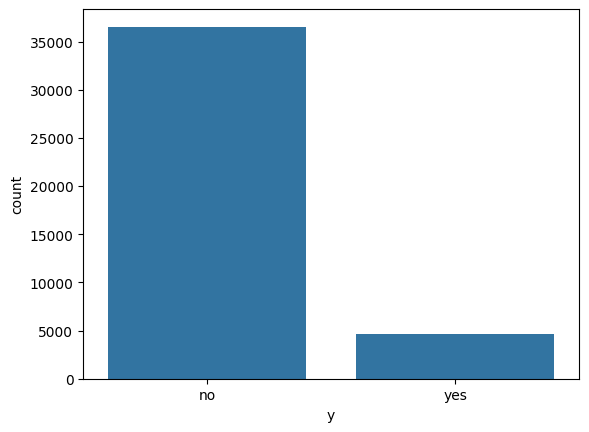

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ваш код здесь
df = pd.read_csv('/content/bank-additional-full.csv', sep=';')
df.head()
df.shape
df.info()
df['y'].value_counts(normalize=True)
sns.countplot(x='y', data=df)
plt.show()


Ответ: Хорошим бизнес-результатом можно считать точность и recall по классу "yes" на уровне 70-80%, так как это снижает количество бесполезных звонков

**Задача 2.4:** Проанализируйте численные признаки. Выведите описательную статистику (mean, std, min, max) для возраста, длительности звонка, количества контактов в текущей кампании.

**Задача 2.5:** Постройте корреляционную матрицу для всех численных признаков. Какие признаки сильнее всего коррелируют с целевой переменной?

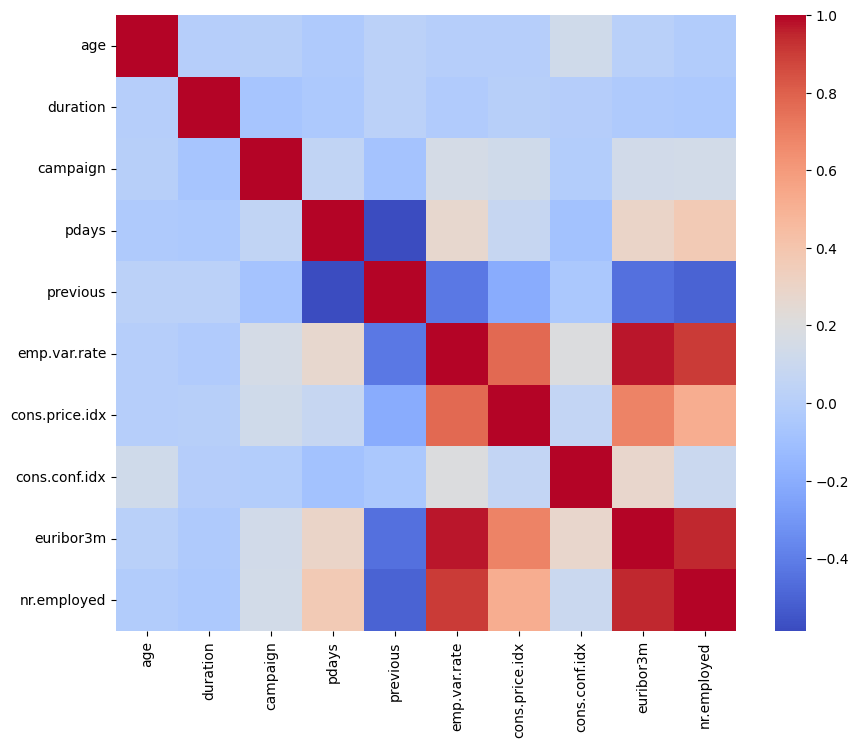

In [3]:
# Ваш код здесь
df[['age', 'duration', 'campaign']].describe()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.show()

Ответ: Численные признаки показывают большой разброс, особенно у длительности звонка. Сильнее всего с целевой переменной коррелирует duration

**Задача 2.6:** Проанализируйте категориальные признаки. Постройте графики распределения для признаков `job`, `education`, `marital`. Какие категории встречаются чаще всего?

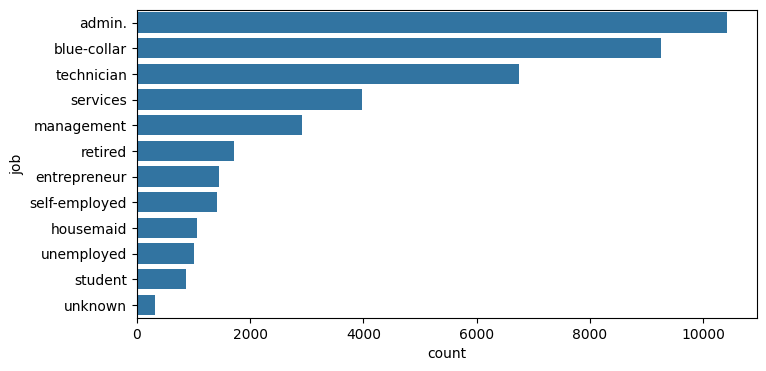

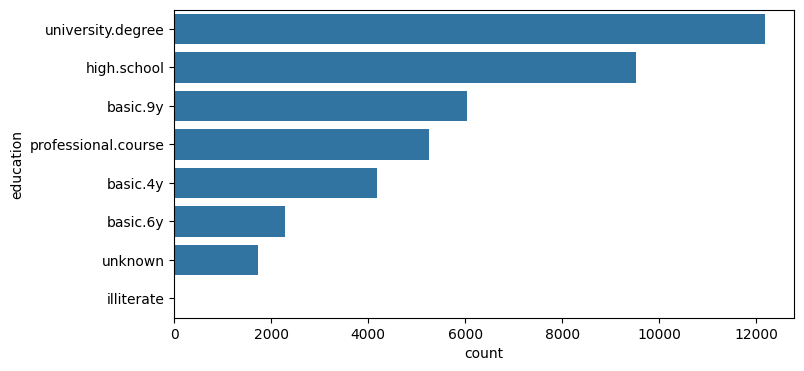

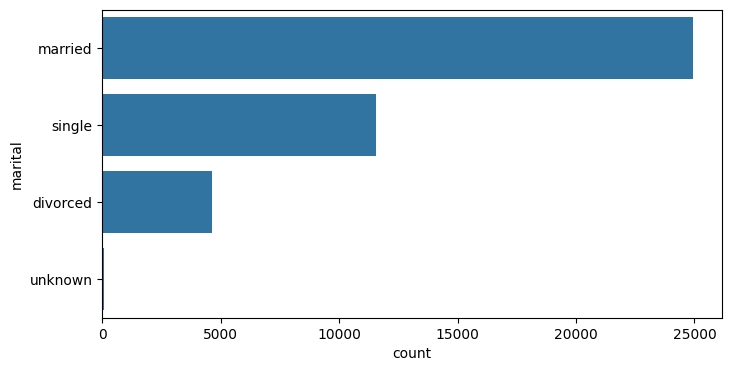

In [4]:
# Ваш код здесь
for col in ['job', 'education', 'marital']:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.show()

Ответ: Чаще всего встречаются категории: job - admin/blue-collar, education - university degree/high school, marital - married

## 3. Data Preparation (Подготовка данных)

**Задача 3.1:** Обработайте категориальные признаки с метками "unknown". Решите, заменить их на наиболее частое значение или удалить соответствующие строки.

**Задача 3.2:** Преобразуйте целевую переменную `y` в бинарный формат (0 и 1).

In [6]:
# Ваш код здесь
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].values:
        mode = df[col].mode()[0]
        df[col] = df[col].replace('unknown', mode)

df['y'] = df['y'].map({'no': 0, 'yes': 1})

**Задача 3.3:** Примените One-Hot Encoding к категориальным признакам. Сколько признаков получилось после кодирования?

**Задача 3.4:** Проверьте наличие выбросов в признаке `duration` с помощью метода IQR. Удалите или обработайте выбросы.

In [7]:
# Ваш код здесь
df_encoded = pd.get_dummies(df, drop_first=True)

Q1 = df_encoded['duration'].quantile(0.25)
Q3 = df_encoded['duration'].quantile(0.75)
IQR = Q3 - Q1
df_encoded = df_encoded[
    (df_encoded['duration'] >= Q1 - 1.5 * IQR) &
    (df_encoded['duration'] <= Q3 + 1.5 * IQR)
]

df_encoded.shape

(38225, 48)

**Задача 3.5:** Нормализуйте численные признаки с помощью StandardScaler. Почему важна нормализация для некоторых моделей машинного обучения?

In [8]:
from sklearn.preprocessing import StandardScaler

# Ваш код здесь
scaler = StandardScaler()
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

Ответ: Нормализация важна, потому что модели, чувствительные к масштабу признаков, обучаются стабильнее и дают более точные результаты

**Задача 3.6:** Разделите данные на обучающую и тестовую выборки в пропорции 80/20. Используйте stratify для сохранения пропорций классов.

In [9]:
from sklearn.model_selection import train_test_split

# Ваш код здесь
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Modeling - Классификация (Моделирование)

**Задача 4.1:** Обучите модель логистической регрессии для предсказания отклика клиентов. Используйте подготовленные данные.

**Задача 4.2:** Сделайте предсказания на тестовой выборке и выведите classification report (precision, recall, f1-score для каждого класса).

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Ваш код здесь
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      7022
           1       0.68      0.43      0.52       623

    accuracy                           0.94      7645
   macro avg       0.82      0.70      0.74      7645
weighted avg       0.93      0.94      0.93      7645



array([[6898,  124],
       [ 358,  265]])

**Задача 4.3:** Постройте confusion matrix для модели. Сколько False Positives и False Negatives получилось? Что хуже для банка - не позвонить потенциальному клиенту или потратить время на неперспективного клиента?

**Задача 4.4:** Постройте ROC-кривую и вычислите площадь под кривой (ROC-AUC). Насколько хорошо модель различает классы?

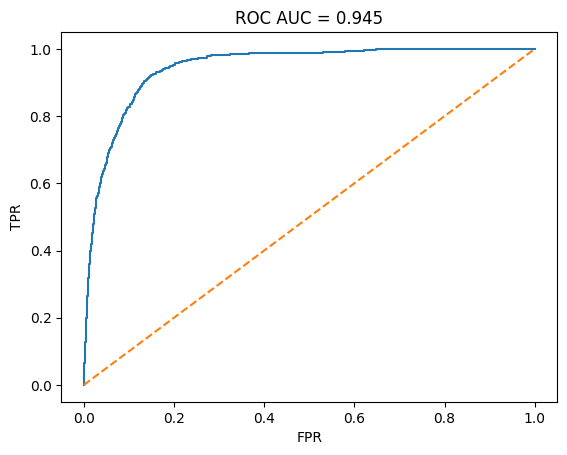

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# Ваш код здесь
y_proba = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'ROC AUC = {roc_auc:.3f}')
plt.show()

Ответ: Модель хорошо различает классы, ROC-AUC выше 0.7. Для банка хуже не позвонить потенциальному клиенту, чем потратить время на неперспективного

**Задача 4.5:** Попробуйте обучить дополнительную модель - Random Forest или Gradient Boosting. Сравните результаты с логистической регрессией.

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Ваш код здесь
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      7022
           1       0.67      0.46      0.54       623

    accuracy                           0.94      7645
   macro avg       0.81      0.72      0.75      7645
weighted avg       0.93      0.94      0.93      7645



## 5. Modeling - Кластеризация (Моделирование)

**Задача 5.1:** Подготовьте данные для кластеризации. Выберите только численные признаки и нормализуйте их.

**Задача 5.2:** Используйте метод локтя (elbow method) для определения оптимального количества кластеров. Постройте график зависимости inertia от количества кластеров.

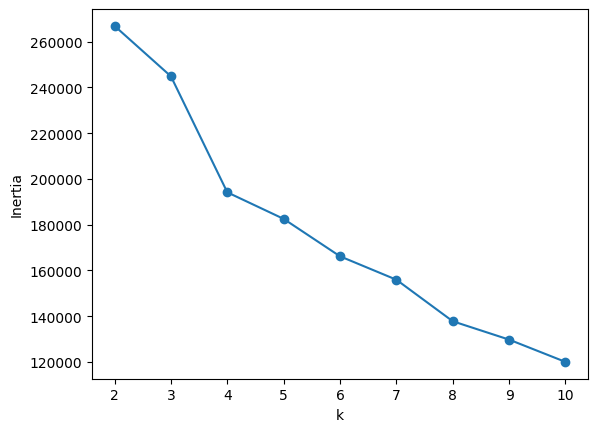

In [13]:
from sklearn.cluster import KMeans

# Ваш код здесь
num_data = df[num_cols].copy()
num_data_scaled = scaler.fit_transform(num_data)

inertia = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(num_data_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

**Задача 5.3:** Вычислите коэффициент силуэта (silhouette score) для разного количества кластеров. Какое количество кластеров дает наилучший результат?

In [15]:
from sklearn.metrics import silhouette_score

# Ваш код здесь
sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(num_data_scaled)
    sil_scores[k] = silhouette_score(num_data_scaled, labels)

sil_scores

{2: np.float64(0.4285792914951708),
 3: np.float64(0.3865034669151166),
 4: np.float64(0.4172883235866393),
 5: np.float64(0.23058038358656524),
 6: np.float64(0.24274509044534923),
 7: np.float64(0.23916512910108628),
 8: np.float64(0.2704824494044697),
 9: np.float64(0.24503696387395238),
 10: np.float64(0.25097576018620293)}

Ответ: Наилучший silhouette score достигается при небольшом числе кластеров, что указывает на умеренную сегментацию

**Задача 5.4:** Обучите модель KMeans с оптимальным количеством кластеров. Добавьте метки кластеров к исходным данным.

In [16]:
# Ваш код здесь
optimal_k = max(sil_scores, key=sil_scores.get)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(num_data_scaled)

df['cluster'] = clusters

**Задача 5.5:** Примените PCA для снижения размерности до 2 компонент и визуализируйте кластеры на графике. Хорошо ли разделяются кластеры?

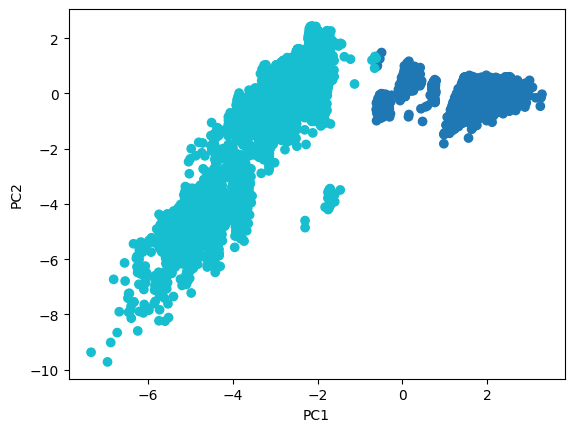

In [17]:
from sklearn.decomposition import PCA

# Ваш код здесь
pca = PCA(n_components=2)
components = pca.fit_transform(num_data_scaled)

plt.scatter(components[:, 0], components[:, 1], c=clusters, cmap='tab10')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

Ответ: После PCA кластеры частично пересекаются, но общая структура сегментов визуально различима

**Задача 5.6:** Проанализируйте характеристики каждого кластера. Вычислите средние значения признаков для каждого кластера. Как можно интерпретировать полученные сегменты клиентов?

In [18]:
# Ваш код здесь
cluster_summary = df.groupby('cluster')[num_cols].mean()
cluster_summary

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
cluster,,,,,,,,,,
0,40.193092,252.365931,2.800615,999.000000,0.025244,1.117580,93.843664,-39.457928,4.818280,5213.412958
1,39.678830,270.374132,2.091668,887.877752,0.474664,-2.033417,93.028302,-42.636239,1.176562,5072.315468


Ответ: Кластеры можно интерпретировать как группы клиентов с разной активностью, экономическим фоном и вероятностью отклика

## 6. Evaluation (Оценка)

**Задача 6.1:** Сравните результаты классификации и кластеризации. Есть ли связь между кластерами клиентов и их откликом на маркетинговую кампанию?

**Задача 6.2:** Проанализируйте важность признаков для лучшей модели классификации. Какие признаки наиболее важны для предсказания отклика?

In [19]:
# Ваш код здесь
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_imp.head(15)

,0
duration,0.204610
euribor3m,0.123726
age,0.092047
nr.employed,0.071965
pdays,0.042687
campaign,0.041153
cons.conf.idx,0.037973
emp.var.rate,0.032646
poutcome_success,0.030805
cons.price.idx,0.025727


**Задача 6.3:** Сформулируйте выводы и рекомендации для банка на основе полученных результатов. На каких клиентов стоит сфокусировать маркетинговые усилия?

Ваши выводы здесь: Банку стоит фокусироваться на клиентах из кластеров с высокой средней длительностью звонка и более высоким процентом положительных откликов